In [107]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import math
%matplotlib inline

In [108]:
x = np.linspace(1,4,1000)
y = np.log(x)

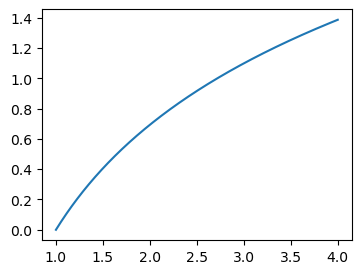

In [109]:
plt.figure(figsize = (4,3))
plt.plot(x,y)
plt.show()

In [110]:
limSup = 4
limInf = 1

areaReal = limSup*(np.log(limSup) - 1) - limInf*(np.log(limInf) - 1)
print(areaActual)

2.5451774444795623


In [111]:
def errorIntegral(areaExacta,areaCalculada):
    return abs(100 * (areaExacta - areaCalculada) / areaExacta)

In [112]:
#Integral por Metodo Del Trapecio
def integralTrapecio(f, a, b, N):
    h = (b-a)/N
    t_x = np.linspace(a,b,N+1)
    t_y = f(t_x)
    area = (h/2) * (t_y[0] +2 *(np.sum(t_y[1:N])) + t_y[N])
    return area

In [113]:
areaCalc = integralTrapecio(lambda v: np.log(v),limInf, limSup,1000)
error = errorIntegral(areaReal,areaCalc)

print(f"Area Verdadera: {areaReal}, Area Calculada: {areaCalc}, Error: {error}%")

Area Verdadera: 2.5451774444795623, Area Calculada: 2.5451768819797835, Error: 2.2100611490790774e-05%


In [114]:
#Usando scipy.integrate
x2 = np.linspace(limInf,limSup,1001)
y2 = np.log(x2)
areaCalc2 = integrate.trapezoid(y2,x2)
error2 = errorIntegral(areaReal,areaCalc2)

print(f"Area Verdadera: {areaReal}, Area Calculada: {areaCalc2}, Error: {error2}%")

Area Verdadera: 2.5451774444795623, Area Calculada: 2.545176881979784, Error: 2.2100611473342512e-05%


In [115]:
#Integral por metodo de Simpson
areaSimpson = integrate.simpson(y2,x=x2)
errorSimpson = errorIntegral(areaReal,areaSimpson)

print(f"Area Verdadera: {areaReal}, Area Calculada: {areaSimpson}, Error: {errorSimpson}%")

Area Verdadera: 2.5451774444795623, Area Calculada: 2.5451774444786768, Error: 3.479183293729427e-11%


In [116]:
#Area por Cuadratura

areaQuad, errorQuad = integrate.quad(np.log,limInf,limSup)
print(f"Area Verdadera: {areaReal}, Area Calculada: {areaQuad}, Error: {errorQuad}%")

Area Verdadera: 2.5451774444795623, Area Calculada: 2.5451774444795623, Error: 1.2977384712512609e-12%


In [122]:
#Integral Por Montecarlo
def integralMontecarlo(a,b,N, radio):
    r_x = np.random.uniform(a,b,N)
    r_y = np.random.uniform(a,b,N)
    puntosDentro = 0
    puntosDentro += np.sum((r_x**2 + r_y**2) <= radio**2)
    return 4 * (radio**2 * puntosDentro/N)
    
radio = 1
areaRealMontecarlo = np.pi * radio ** 2
areaMontecarlo = integralMontecarlo(0,1,100,radio)
errorMontecarlo = errorIntegral(areaRealMontecarlo, areaMontecarlo)

print(f"Area Verdadera: {areaRealMontecarlo}, Area Calculada: {areaMontecarlo}, Error: {errorMontecarlo}%")

Area Verdadera: 3.141592653589793, Area Calculada: 2.96, Error: 5.7802736895979585%
